# 02 - Graph Construction (k-NN)

**Goal:** Build k-NN graphs from CICIoT2023 for GNN.  
Sample 100K train (stratified), Dirichlet split into 5 clients. Each client builds its own graph.

In [1]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)

OUT = Path('D:/Project/riset/fl-gnn/dataset-clean')
print('Libraries ready.')

Libraries ready.


In [2]:
K = 15  # number of neighbors
N_SAMPLE_TRAIN = 100_000  # train samples
N_SAMPLE_TEST = 20_000    # test samples
NUM_CLIENTS = 5
DIRICHLET_ALPHA = 0.5
RANDOM_STATE = 42

print(f'k={K}, train_sample={N_SAMPLE_TRAIN}, test_sample={N_SAMPLE_TEST}')

k=15, train_sample=100000, test_sample=20000


## 1. Load & Sample Data

In [3]:
data = np.load(OUT / 'train.npz')
X_full, y_full = data['X'], data['y']
print(f'Train full: {X_full.shape}, {y_full.shape}, {X_full.dtype}')

Train full: (4114778, 44), (4114778,), float32


In [4]:
def stratified_sample(X, y, n_samples, random_state=42):
    """Stratified sampling preserving class distribution."""
    classes = np.unique(y)
    n_classes = len(classes)
    n_per_class = n_samples // n_classes

    indices = []
    rng = np.random.default_rng(random_state)
    for c in classes:
        idx_c = np.where(y == c)[0]
        rng.shuffle(idx_c)
        n_take = min(n_per_class, len(idx_c))
        indices.append(idx_c[:n_take])

    idx = np.concatenate(indices)
    rng.shuffle(idx)
    return X[idx], y[idx], idx

print('Stratified sampling train...')
X_train_sampled, y_train_sampled, idx_train = stratified_sample(
    X_full, y_full, N_SAMPLE_TRAIN, RANDOM_STATE
)
print(f'Sampled train: {X_train_sampled.shape}')
print(f'Distribution: {np.bincount(y_train_sampled).tolist()[:8]}...')

Stratified sampling train...
Sampled train: (80717, 44)
Distribution: [388, 2941, 646, 609, 2941, 2941, 2941, 2941]...


In [5]:
# Load test data
test_npz_path = OUT / 'test.npz'
if test_npz_path.exists():
    test_data = np.load(test_npz_path)
    X_test_full, y_test_full = test_data['X'], test_data['y']
    print(f'Test full: {X_test_full.shape}')

    X_test_sampled, y_test_sampled, idx_test = stratified_sample(
        X_test_full, y_test_full, N_SAMPLE_TEST, RANDOM_STATE
    )
    print(f'Sampled test: {X_test_sampled.shape}')
else:
    # Fallback: split from train
    print('No test.npz found, using 20K from train as test...')
    X_test_sampled = X_train_sampled[-N_SAMPLE_TEST:]
    y_test_sampled = y_train_sampled[-N_SAMPLE_TEST:]
    X_train_sampled = X_train_sampled[:-N_SAMPLE_TEST]
    y_train_sampled = y_train_sampled[:-N_SAMPLE_TEST]

Test full: (1176851, 44)
Sampled test: (16286, 44)


In [ ]:
# Save sampled data for reuse in downstream notebooks
print('Saving sampled data...')
np.savez_compressed(OUT / 'sampled_train.npz', X=X_train_sampled, y=y_train_sampled)
np.savez_compressed(OUT / 'sampled_test.npz', X=X_test_sampled, y=y_test_sampled)
print(f'  sampled_train: {X_train_sampled.shape}')
print(f'  sampled_test:  {X_test_sampled.shape}')

## 2. Dirichlet Split (Non-IID)

In [6]:
def dirichlet_split(y, n_clients, alpha=0.5, random_state=42):
    """Non-IID split using Dirichlet distribution."""
    rng = np.random.default_rng(random_state)
    n_samples = len(y)
    n_classes = np.unique(y).shape[0]

    label_dist = rng.dirichlet([alpha] * n_clients, size=n_classes)

    class_indices = [np.where(y == c)[0] for c in range(n_classes)]
    client_indices = [[] for _ in range(n_clients)]

    for c in range(n_classes):
        idx_c = class_indices[c].copy()
        rng.shuffle(idx_c)
        dist = label_dist[c]
        dist = dist / dist.sum() * len(idx_c)
        dist = dist.astype(int)
        diff = len(idx_c) - dist.sum()
        if diff > 0:
            dist[-1] += diff
        else:
            dist[0] -= diff

        start = 0
        for i in range(n_clients):
            end = start + dist[i]
            client_indices[i].extend(idx_c[start:end].tolist())
            start = end

    return [np.array(idx).astype(np.int32) for idx in client_indices]

print('Creating Dirichlet splits...')
client_indices = dirichlet_split(y_train_sampled, NUM_CLIENTS, DIRICHLET_ALPHA, RANDOM_STATE)

for i, idx in enumerate(client_indices):
    labels = y_train_sampled[idx]
    print(f'Client {i}: {len(idx)} nodes, {len(np.unique(labels))} classes')

# Save split metadata
split_info = {
    'num_clients': NUM_CLIENTS,
    'dirichlet_alpha': DIRICHLET_ALPHA,
    'total_samples': N_SAMPLE_TRAIN,
    'client_sizes': [len(idx) for idx in client_indices]
}
with open(OUT / 'split_info.json', 'w') as f:
    json.dump(split_info, f)
print('Split info saved.')

Creating Dirichlet splits...
Client 0: 22505 nodes, 34 classes
Client 1: 15723 nodes, 33 classes
Client 2: 11795 nodes, 33 classes
Client 3: 17473 nodes, 34 classes
Client 4: 13221 nodes, 34 classes
Split info saved.


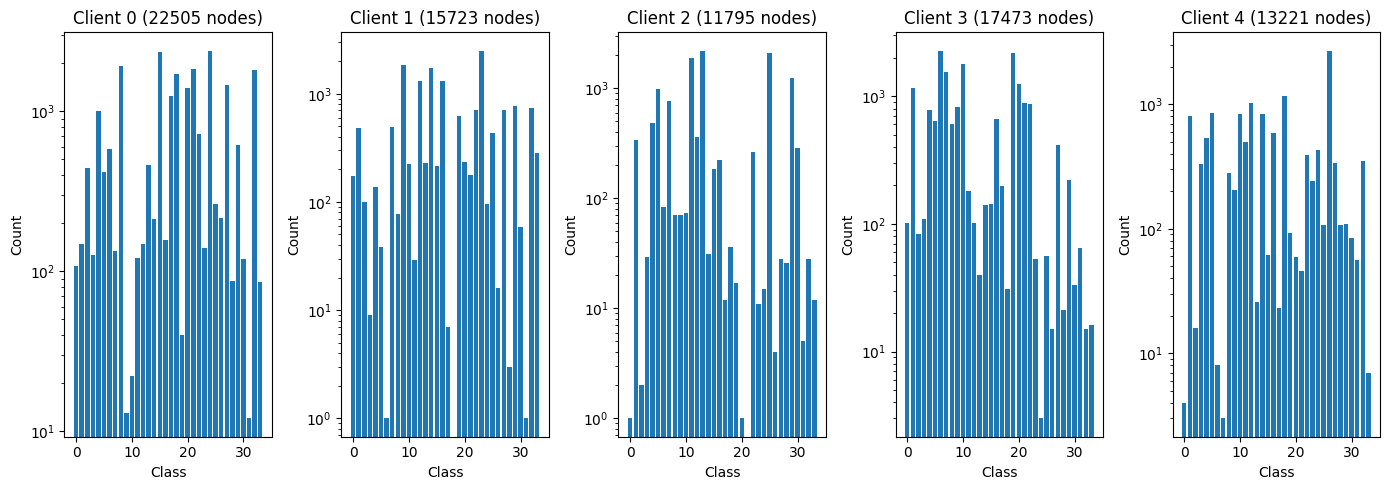

In [7]:
plt.figure(figsize=(14, 5))
for i in range(NUM_CLIENTS):
    plt.subplot(1, NUM_CLIENTS, i+1)
    labels = y_train_sampled[client_indices[i]]
    counts = Counter(labels)
    plt.bar(counts.keys(), counts.values(), width=0.8)
    plt.title(f'Client {i} ({len(labels)} nodes)')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.yscale('log')
plt.tight_layout()
plt.show()

## 3. Build k-NN Graph per Client

In [8]:
def build_knn_graph(X, k=15, metric='cosine'):
    """Build k-NN graph, returns edge_index in COO format (2, num_edges) int64."""
    n = X.shape[0]
    k = min(k, n - 1)

    print(f'  Building k-NN (k={k}) on {n} nodes x {X.shape[1]} features...')
    nn = NearestNeighbors(n_neighbors=k, metric=metric, algorithm='brute', n_jobs=-1)
    nn.fit(X)
    distances, indices = nn.kneighbors(X, n_neighbors=k)

    # edge_index COO: [2, num_edges]
    row = np.repeat(np.arange(n), k)
    col = indices.ravel()

    # Undirected: add reverse edges
    edge_index = np.stack([np.concatenate([row, col]),
                           np.concatenate([col, row])], axis=0).astype(np.int64)

    print(f'  Edge index shape: {edge_index.shape}, {edge_index.dtype}')
    return edge_index, distances

print('\n=== BUILDING CLIENT GRAPHS ===')
client_graphs = {}
for i in range(NUM_CLIENTS):
    idx = client_indices[i]
    X_c = X_train_sampled[idx]
    y_c = y_train_sampled[idx]
    print(f'\nClient {i} ({len(X_c)} nodes):')
    edge_index, dist = build_knn_graph(X_c, k=K)

    path = OUT / f'client_{i}_graph.npz'
    np.savez_compressed(path, X=X_c, y=y_c, edge_index=edge_index)
    print(f'  Saved: {path.name}')

    # Track sizes
    client_graphs[i] = {
        'num_nodes': len(X_c),
        'num_edges': edge_index.shape[1],
        'n_classes': len(np.unique(y_c))
    }

print('\nClient graphs built and saved.')


=== BUILDING CLIENT GRAPHS ===

Client 0 (22505 nodes):
  Building k-NN (k=15) on 22505 nodes x 44 features...
  Edge index shape: (2, 675150), int64
  Saved: client_0_graph.npz

Client 1 (15723 nodes):
  Building k-NN (k=15) on 15723 nodes x 44 features...
  Edge index shape: (2, 471690), int64
  Saved: client_1_graph.npz

Client 2 (11795 nodes):
  Building k-NN (k=15) on 11795 nodes x 44 features...
  Edge index shape: (2, 353850), int64
  Saved: client_2_graph.npz

Client 3 (17473 nodes):
  Building k-NN (k=15) on 17473 nodes x 44 features...
  Edge index shape: (2, 524190), int64
  Saved: client_3_graph.npz

Client 4 (13221 nodes):
  Building k-NN (k=15) on 13221 nodes x 44 features...
  Edge index shape: (2, 396630), int64
  Saved: client_4_graph.npz

Client graphs built and saved.


In [9]:
print('\n=== BUILDING TEST GRAPH ===')
edge_index_test, _ = build_knn_graph(X_test_sampled, k=K)
np.savez_compressed(OUT / 'test_graph.npz', X=X_test_sampled, y=y_test_sampled, edge_index=edge_index_test)
print('Test graph saved.')


=== BUILDING TEST GRAPH ===
  Building k-NN (k=15) on 16286 nodes x 44 features...
  Edge index shape: (2, 488580), int64
Test graph saved.


In [ ]:
# Build full training graph for centralized (non-FL) baseline
print('\n=== BUILDING CENTRALIZED TRAINING GRAPH ===')
edge_index_full, _ = build_knn_graph(X_train_sampled, k=K)
np.savez_compressed(OUT / 'centralized_train_graph.npz', X=X_train_sampled, y=y_train_sampled, edge_index=edge_index_full)
print('Centralized train graph saved.')

In [10]:
print('\n=== GRAPH SUMMARY ===')
print(f'{"Graph":<15} {"Nodes":<10} {"Edges":<12} {"Classes":<8}')
print('-'*45)
for i, info in client_graphs.items():
    print(f'{"Client_"+str(i):<15} {info["num_nodes"]:<10} {info["num_edges"]:<12} {info["n_classes"]:<8}')
print(f'{"Test":<15} {len(X_test_sampled):<10} {edge_index_test.shape[1]:<12} {len(np.unique(y_test_sampled)):<8}')
print('-'*45)
total_nodes = sum(info['num_nodes'] for info in client_graphs.values())
total_edges = sum(info['num_edges'] for info in client_graphs.values())
print(f'Train total: {total_nodes} nodes, {total_edges} edges')


=== GRAPH SUMMARY ===
Graph           Nodes      Edges        Classes 
---------------------------------------------
Client_0        22505      675150       34      
Client_1        15723      471690       33      
Client_2        11795      353850       33      
Client_3        17473      524190       34      
Client_4        13221      396630       34      
Test            16286      488580       34      
---------------------------------------------
Train total: 80717 nodes, 2421510 edges
